# Market Regime Detection via Hidden Markov Model (HMM)

Unsupervised regime detection using `hmmlearn.GaussianHMM`.

**Features used:**
- Daily log-returns
- Rolling volatility (20-day)
- Rolling momentum (20-day)
- Volume ratio (relative to 20-day avg)

**Regimes (n_components=3):** Bear / Neutral / Bull (labelled by mean return)

In [39]:
# ── dependencies ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import seaborn as sns

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

plt.style.use('dark_background')
sns.set_palette('husl')
print('imports ok')

imports ok


## 1. Load Data

In [40]:
# ── load from DeltaLake (S3/MinIO) with local HDF5 fallback ──────────────────
import os, pathlib

HDF5_PATH = pathlib.Path('stocks_data_latest.h5')
S3_ENDPOINT = 'http://192.168.1.30'
S3_TABLE    = 's3://delta-table-storage/stocks'
SYMBOL      = 'VNINDEX'   # benchmark index; change to any symbol in watchlist
YEARS_BACK  = 10

def load_from_delta():
    import deltalake as dl
    storage_opts = {
        'AWS_ACCESS_KEY_ID':     os.environ.get('MINIO_ACCESS_KEY', 'CzOwnLkEDXQy951AOqes'),
        'AWS_SECRET_ACCESS_KEY': os.environ.get('MINIO_SECRET_KEY', 'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S'),
        'AWS_ENDPOINT_URL':      S3_ENDPOINT,
        'AWS_ALLOW_HTTP':        'true',
        'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    }
    tbl = dl.DeltaTable(S3_TABLE, storage_options=storage_opts)
    df  = tbl.to_pandas()
    df['date'] = pd.to_datetime(df['date'])
    return df

def load_from_hdf5():
    with pd.HDFStore(HDF5_PATH, 'r') as store:
        df = store['stocks']
    # Wide panel uses DatetimeIndex; reset_index() would move date into a column and
    # .loc[:, symbol_cols] would drop it — index becomes 0..n and dates "disappear".
    if isinstance(df.index, pd.DatetimeIndex):
        return df.sort_index()
    if isinstance(df.index, pd.MultiIndex):
        return df
    df = df.reset_index()
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
    return df

# --- try delta first, fall back to hdf5 ---
try:
    print('Loading from DeltaLake …')
    raw = load_from_hdf5()
    print(f'  DeltaLake OK — {len(raw):,} rows')
except Exception as e:
    print(f'  DeltaLake failed ({e}), falling back to HDF5 …')
    raw = load_from_hdf5()
    print(f'  HDF5 OK — {len(raw):,} rows')


# Build single-symbol OHLCV frame for strategy development
SYMBOL = "VNINDEX"  # change to any symbol in watchlist

# df columns are MultiIndex: (field, symbol)
df_sym = raw.xs(SYMBOL, axis=1, level='symbol').copy()
df_sym = df_sym[["open", "high", "low", "close", "volume"]].dropna().copy()
df_sym.index = pd.to_datetime(df_sym.index)
df_sym = df_sym[~df_sym.index.duplicated(keep='last')].sort_index()
print(f'Symbol: {SYMBOL}  |  rows: {len(df_sym)}  |  {df_sym.index[0].date()} → {df_sym.index[-1].date()}')


Loading from DeltaLake …
  DeltaLake OK — 2,500 rows
Symbol: VNINDEX  |  rows: 2500  |  2016-04-04 → 2026-04-03


## 2. Feature Engineering

In [41]:
W = 20  # rolling window

feat = pd.DataFrame(index=df_sym.index)

# log-return
feat['log_ret']    = np.log(df_sym['close'] / df_sym['close'].shift(1))

# realised volatility (rolling std of log-returns)
feat['volatility'] = feat['log_ret'].rolling(W).std()

# momentum (log return over W days)
feat['momentum']   = np.log(df_sym['close'] / df_sym['close'].shift(W))

# volume ratio (today / W-day avg)
feat['vol_ratio']  = df_sym['volume'] / df_sym['volume'].rolling(W).mean()

feat = feat.dropna()
print(f'Feature matrix: {feat.shape}  |  {feat.index[0].date()} → {feat.index[-1].date()}')
feat.describe().round(4)

Feature matrix: (2480, 4)  |  2016-05-05 → 2026-04-03


,log_ret,volatility,momentum,vol_ratio
count,2480.0000,2480.0000,2480.0000,2480.0000
mean,0.0004,0.0104,0.0086,1.0127
std,0.0118,0.0055,0.0575,0.2242
min,-0.0691,0.0030,-0.3220,0.3120
25%,-0.0042,0.0065,-0.0162,0.8607
50%,0.0014,0.0086,0.0138,0.9926
75%,0.0063,0.0132,0.0431,1.1264
max,0.0655,0.0331,0.1593,2.1959


## 3. Fit GaussianHMM

In [42]:
N_REGIMES   = 3      # Bear / Neutral / Bull
N_ITER      = 200
RANDOM_SEED = 42

FEATURE_COLS = ['log_ret', 'volatility', 'momentum', 'vol_ratio']

scaler = StandardScaler()
X      = scaler.fit_transform(feat[FEATURE_COLS].values)

model = GaussianHMM(
    n_components=N_REGIMES,
    covariance_type='full',
    n_iter=N_ITER,
    random_state=RANDOM_SEED,
    tol=1e-4,
)
model.fit(X)
print(f'Converged: {model.monitor_.converged}  |  log-likelihood: {model.score(X):.2f}')

hidden_states = model.predict(X)
state_probs   = model.predict_proba(X)   # shape (T, n_regimes)

feat['state'] = hidden_states

Converged: True  |  log-likelihood: -10067.10


In [43]:
# ── label states by mean log-return (lowest=Bear, highest=Bull) ──────────────
state_mean_ret = {
    s: feat.loc[feat['state'] == s, 'log_ret'].mean()
    for s in range(N_REGIMES)
}
ranked = sorted(state_mean_ret, key=state_mean_ret.get)
label_map   = {ranked[0]: 'Bear',    ranked[1]: 'Neutral', ranked[2]: 'Bull'}
color_map   = {ranked[0]: '#e74c3c', ranked[1]: '#f39c12', ranked[2]: '#2ecc71'}

feat['regime'] = feat['state'].map(label_map)

for s in ranked:
    sub = feat[feat['state'] == s]
    print(f"State {s} → {label_map[s]:7s}  "
          f"mean_ret={state_mean_ret[s]*100:.3f}%  "
          f"count={len(sub)}  frac={len(sub)/len(feat):.1%}")

State 1 → Bear     mean_ret=-0.223%  count=503  frac=20.3%
State 2 → Neutral  mean_ret=0.103%  count=1101  frac=44.4%
State 0 → Bull     mean_ret=0.117%  count=876  frac=35.3%


## 4. Transition Matrix & Stationary Distribution

In [44]:
labels_ordered = [label_map[s] for s in ranked]
trans = pd.DataFrame(
    model.transmat_[[ranked[i] for i in range(N_REGIMES)], :][:, [ranked[i] for i in range(N_REGIMES)]],
    index=labels_ordered,
    columns=labels_ordered,
).round(4)

print('Transition matrix (row=from, col=to):')
display(trans)

# stationary distribution: left eigenvector of transmat with eigenvalue 1
evals, evecs = np.linalg.eig(model.transmat_.T)
stat = evecs[:, np.argmax(evals)].real
stat /= stat.sum()
stat_df = pd.Series({label_map[s]: stat[s] for s in range(N_REGIMES)})
print('\nStationary distribution:')
print(stat_df.round(4))

Transition matrix (row=from, col=to):


,Bear,Neutral,Bull
Bear,0.9622,0.0000,0.0378
Neutral,0.0037,0.9853,0.0110
Bull,0.0187,0.0188,0.9625



Stationary distribution:
Bull       0.3451
Bear       0.2142
Neutral    0.4407
dtype: float64


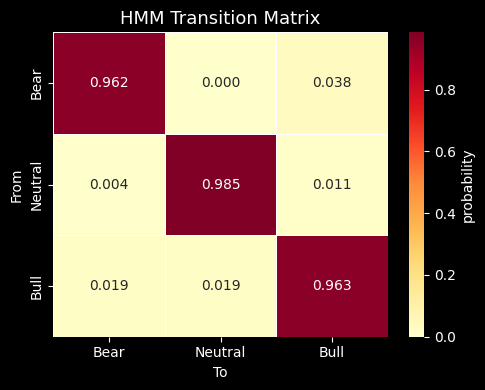

In [45]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    trans, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'probability'}
)
ax.set_title('HMM Transition Matrix', fontsize=13)
ax.set_xlabel('To')
ax.set_ylabel('From')
plt.tight_layout()
plt.show()

## 5. Regime Timeline

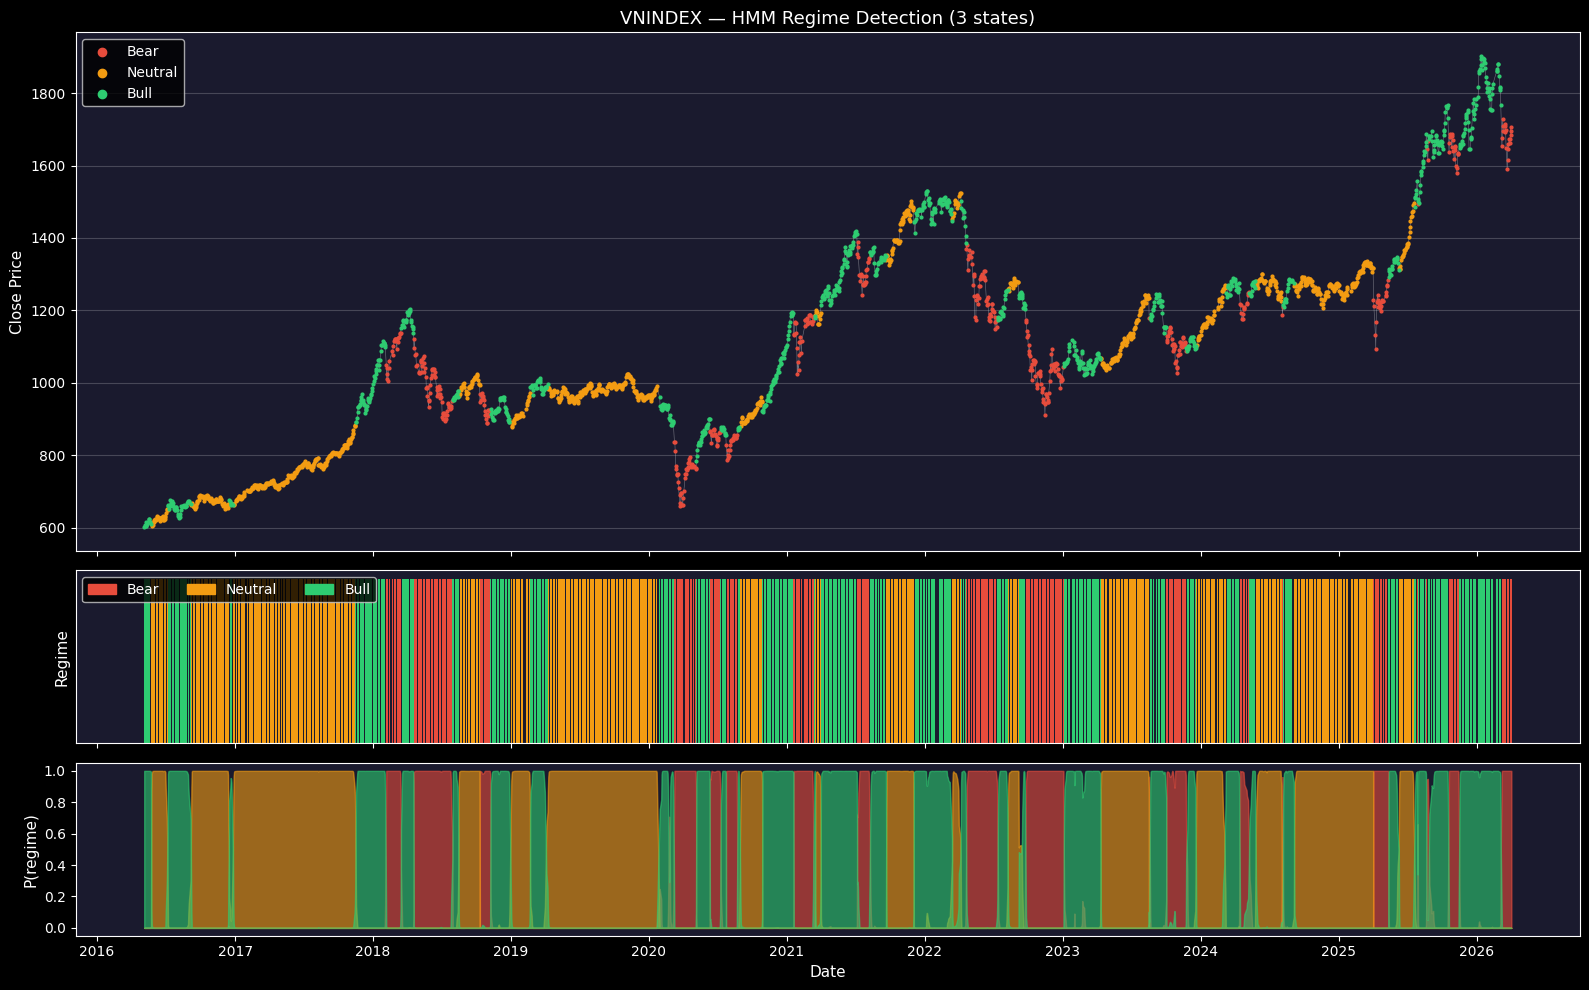

In [46]:
close = df_sym.loc[feat.index, 'close']

fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [3, 1, 1]},
                         sharex=True)

# --- panel 1: price coloured by regime ---
ax = axes[0]
ax.set_facecolor('#1a1a2e')
for state in ranked:
    mask = feat['state'] == state
    ax.scatter(
        feat.index[mask], close[mask],
        c=color_map[state], s=4, label=label_map[state], zorder=3
    )
ax.plot(close.index, close.values, color='white', lw=0.4, alpha=0.4, zorder=2)
ax.set_ylabel('Close Price', fontsize=11)
ax.set_title(f'{SYMBOL} — HMM Regime Detection ({N_REGIMES} states)', fontsize=13)
ax.legend(loc='upper left', markerscale=3)
ax.yaxis.grid(True, alpha=0.2)

# --- panel 2: regime bar ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
regime_num = feat['state'].map({s: i for i, s in enumerate(ranked)})
colors_arr = [color_map[s] for s in feat['state']]
ax2.bar(feat.index, np.ones(len(feat)), color=colors_arr, width=1.5, align='center')
ax2.set_yticks([])
ax2.set_ylabel('Regime', fontsize=11)
patches = [mpatches.Patch(color=color_map[s], label=label_map[s]) for s in ranked]
ax2.legend(handles=patches, loc='upper left', ncol=3)

# --- panel 3: state probabilities ---
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
for i, s in enumerate(ranked):
    ax3.fill_between(feat.index, state_probs[:, s],
                     alpha=0.6, color=color_map[s], label=label_map[s])
ax3.set_ylabel('P(regime)', fontsize=11)
ax3.set_xlabel('Date', fontsize=11)
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

## 6. Regime Statistics

In [47]:
stats_rows = []
for s in ranked:
    sub = feat.loc[feat['state'] == s, 'log_ret']
    ann_ret = sub.mean() * 252
    ann_vol = sub.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    # avg duration via run-length encoding
    changes = (feat['state'] != feat['state'].shift()).cumsum()
    durations = (
        feat[feat['state'] == s]
        .groupby(changes[feat['state'] == s])
        .size()
    )
    stats_rows.append({
        'Regime':         label_map[s],
        'Count':          len(sub),
        'Fraction':       f"{len(sub)/len(feat):.1%}",
        'Ann. Return':    f"{ann_ret:.1%}",
        'Ann. Vol':       f"{ann_vol:.1%}",
        'Sharpe':         f"{sharpe:.2f}",
        'Avg Duration':   f"{durations.mean():.1f} days",
        'Max Duration':   f"{durations.max()} days",
    })

display(pd.DataFrame(stats_rows).set_index('Regime'))

,Count,Fraction,Ann. Return,Ann. Vol,Sharpe,Avg Duration,Max Duration
Regime,,,,,,,
Bear,503,20.3%,-56.2%,32.4%,-1.74,26.5 days,71 days
Neutral,1101,44.4%,26.0%,10.0%,2.59,68.8 days,222 days
Bull,876,35.3%,29.4%,16.1%,1.82,28.3 days,73 days


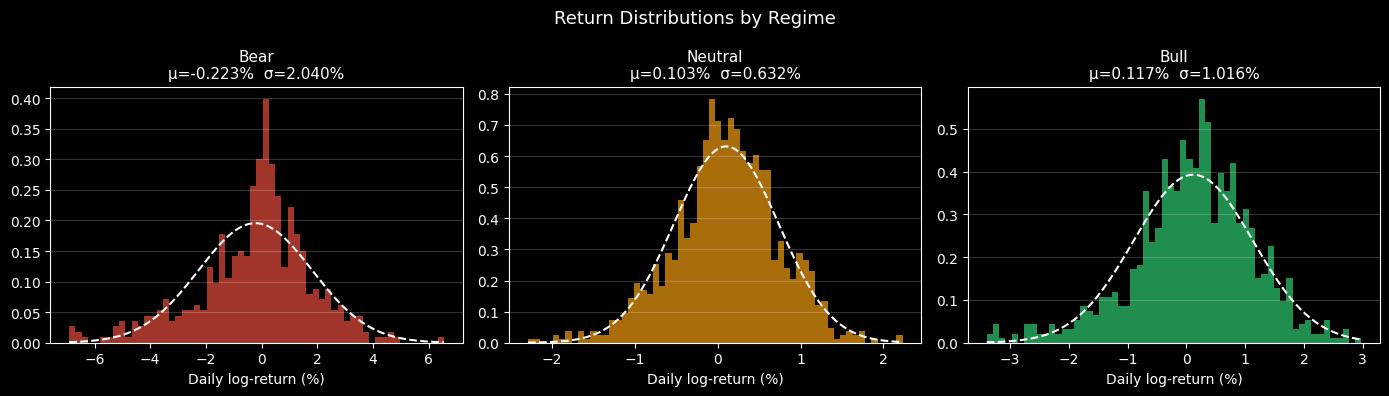

In [48]:
# ── return distributions per regime ──────────────────────────────────────────
fig, axes = plt.subplots(1, N_REGIMES, figsize=(14, 4), sharey=False)

for ax, s in zip(axes, ranked):
    sub = feat.loc[feat['state'] == s, 'log_ret'] * 100
    ax.hist(sub, bins=60, color=color_map[s], alpha=0.7, density=True, edgecolor='none')
    x = np.linspace(sub.min(), sub.max(), 200)
    ax.plot(x, norm.pdf(x, sub.mean(), sub.std()), 'w--', lw=1.5)
    ax.set_title(f"{label_map[s]}\nμ={sub.mean():.3f}%  σ={sub.std():.3f}%", fontsize=11)
    ax.set_xlabel('Daily log-return (%)')
    ax.yaxis.grid(True, alpha=0.2)

fig.suptitle('Return Distributions by Regime', fontsize=13)
fig.tight_layout()
plt.show()

## 7. Model Selection — BIC / AIC across n_components

n=2  ll=-27500369.4  AIC=55000800.8  BIC=55000981.1  conv=True
n=3  ll=-24966409.9  AIC=49932919.7  BIC=49933210.5  conv=True
n=4  ll=-24204286.5  AIC=48408715.0  BIC=48409127.9  conv=True
n=5  ll=-22214713.9  AIC=44429615.8  BIC=44430162.6  conv=True
n=6  ll=-23328966.4  AIC=46658170.8  BIC=46658862.9  conv=True


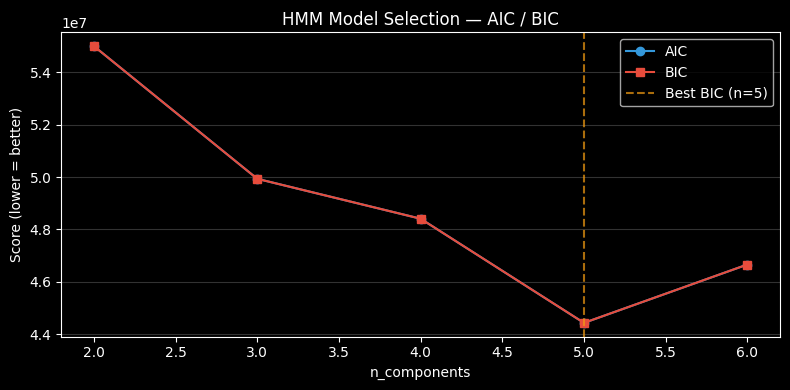

,log-likelihood,AIC,BIC,converged
n,,,,
2,-2.750037e+07,5.500080e+07,5.500098e+07,True
3,-2.496641e+07,4.993292e+07,4.993321e+07,True
4,-2.420429e+07,4.840872e+07,4.840913e+07,True
5,-2.221471e+07,4.442962e+07,4.443016e+07,True
6,-2.332897e+07,4.665817e+07,4.665886e+07,True


In [49]:
results = []
for n in range(2, 7):
    m = GaussianHMM(
        n_components=n, covariance_type='full',
        n_iter=200, random_state=RANDOM_SEED, tol=1e-4
    )
    m.fit(X)
    ll   = m.score(X) * len(X)
    d    = len(FEATURE_COLS)   # observation dimension
    # free params: transmat (n*(n-1)), startprob (n-1), means (n*d), covs (n*d*(d+1)/2)
    k    = n*(n-1) + (n-1) + n*d + n*d*(d+1)//2
    T    = len(X)
    aic  = -2*ll + 2*k
    bic  = -2*ll + k*np.log(T)
    results.append({'n': n, 'log-likelihood': ll, 'AIC': aic, 'BIC': bic,
                    'converged': m.monitor_.converged})
    print(f'n={n}  ll={ll:.1f}  AIC={aic:.1f}  BIC={bic:.1f}  conv={m.monitor_.converged}')

res_df = pd.DataFrame(results).set_index('n')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df.index, res_df['AIC'], 'o-', label='AIC', color='#3498db')
ax.plot(res_df.index, res_df['BIC'], 's-', label='BIC', color='#e74c3c')
best_bic = res_df['BIC'].idxmin()
ax.axvline(best_bic, ls='--', color='#f39c12', alpha=0.7, label=f'Best BIC (n={best_bic})')
ax.set_xlabel('n_components')
ax.set_ylabel('Score (lower = better)')
ax.set_title('HMM Model Selection — AIC / BIC')
ax.legend()
ax.yaxis.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

display(res_df)

## 8. Regime-Conditioned Cumulative Return

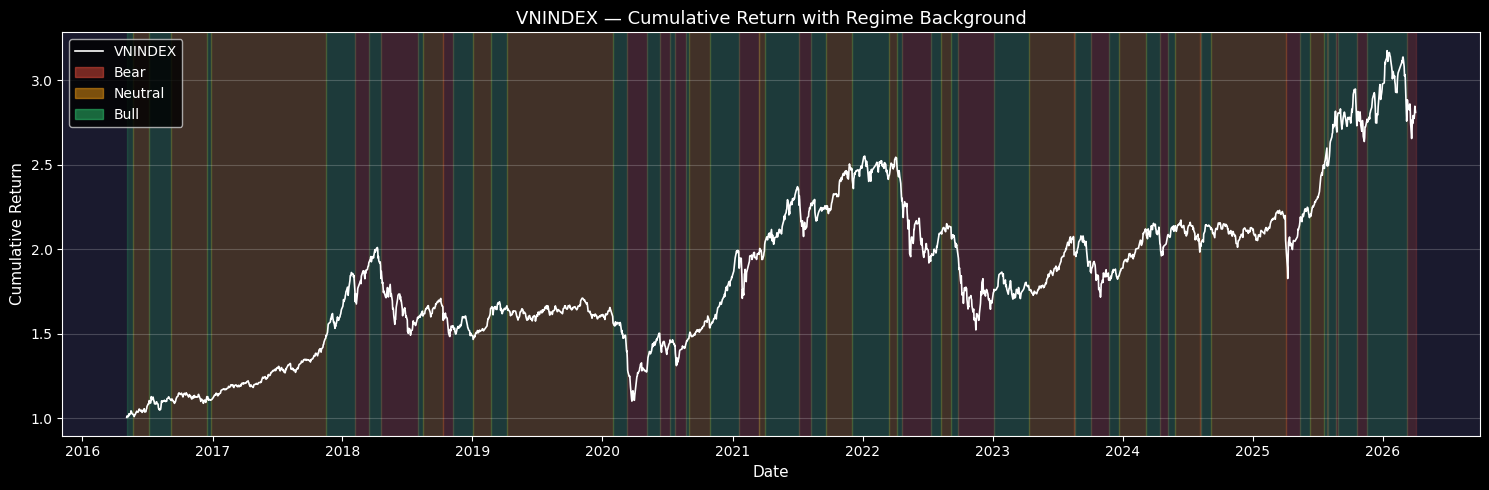

In [50]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_facecolor('#1a1a2e')

cum_total = feat['log_ret'].cumsum().apply(np.exp)
ax.plot(cum_total.index, cum_total.values, color='white', lw=1.2, label=SYMBOL, zorder=5)

# shade background by regime
prev_idx = feat.index[0]
prev_state = feat['state'].iloc[0]
for i in range(1, len(feat)):
    cur_state = feat['state'].iloc[i]
    if cur_state != prev_state or i == len(feat) - 1:
        ax.axvspan(prev_idx, feat.index[i], alpha=0.18,
                   color=color_map[prev_state], zorder=1)
        prev_idx  = feat.index[i]
        prev_state = cur_state

patches = [mpatches.Patch(color=color_map[s], alpha=0.5, label=label_map[s]) for s in ranked]
ax.legend(handles=[ax.lines[0]] + patches, loc='upper left')
ax.set_ylabel('Cumulative Return', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title(f'{SYMBOL} — Cumulative Return with Regime Background', fontsize=13)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

---
## 9. KMeans Regime Detection — Feature Engineering

New feature set designed to capture **trend + volatility + momentum**:

| Feature | Description |
|---------|-------------|
| `log_ret` | Daily log-return |
| `yz_vol` | Yang-Zhang volatility (annualised) — uses OHLC, handles overnight gaps |
| `ma_ratio_50` | close / MA50 − 1 (trend position relative to medium-term average) |
| `ma_ratio_200` | close / MA200 − 1 (trend position relative to long-term average) |
| `rsi` | RSI-14 (momentum oscillator) |

Yang-Zhang is preferred over simple rolling-std because it uses open/high/low/close
to get a less biased estimate of true volatility, especially over overnight gaps.

In [ ]:
# ── Yang-Zhang volatility ─────────────────────────────────────────────────────
def yang_zhang_vol(open_, high, low, close, window=20):
    """
    Yang-Zhang volatility estimator (annualised).
    Combines overnight, open-to-close, and Rogers-Satchell components.
    k chosen to minimise estimation variance (Yang & Zhang 2000).
    """
    # Rogers-Satchell component: captures intraday drift
    rs = (np.log(high / close) * np.log(high / open_) +
          np.log(low  / close) * np.log(low  / open_))

    # Overnight (close-to-open) log-return
    log_co = np.log(open_ / close.shift(1))

    # Open-to-close log-return
    log_oc = np.log(close / open_)

    n = window
    k = 0.34 / (1.34 + (n + 1) / (n - 1))

    var_rs          = rs.rolling(n).mean()
    var_overnight   = log_co.rolling(n).var()
    var_oc          = log_oc.rolling(n).var()

    yz_var = var_overnight + k * var_oc + (1 - k) * var_rs
    return np.sqrt(yz_var.clip(lower=0) * 252)   # annualised


# ── RSI-14 ───────────────────────────────────────────────────────────────────
def calc_rsi(close, period=14):
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))


# ── build KMeans feature matrix ───────────────────────────────────────────────
km_feat = pd.DataFrame(index=df_sym.index)

km_feat['log_ret']      = np.log(df_sym['close'] / df_sym['close'].shift(1))
km_feat['yz_vol']       = yang_zhang_vol(
                              df_sym['open'], df_sym['high'],
                              df_sym['low'],  df_sym['close'], window=20)
km_feat['ma_ratio_50']  = df_sym['close'] / df_sym['close'].rolling(50).mean()  - 1
km_feat['ma_ratio_200'] = df_sym['close'] / df_sym['close'].rolling(200).mean() - 1
km_feat['rsi']          = calc_rsi(df_sym['close'], period=14)

km_feat = km_feat.dropna()
print(f'KMeans feature matrix: {km_feat.shape}  '
      f'| {km_feat.index[0].date()} → {km_feat.index[-1].date()}')
km_feat.describe().round(4)


## 10. KMeans — Choose k (Elbow + Silhouette)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics  import silhouette_score

KM_FEATURE_COLS = ['log_ret', 'yz_vol', 'ma_ratio_50', 'ma_ratio_200', 'rsi']

km_scaler = StandardScaler()
X_km      = km_scaler.fit_transform(km_feat[KM_FEATURE_COLS].values)

inertias   = []
silhouettes = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labels, sample_size=2000,
                                        random_state=RANDOM_SEED))
    print(f'  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(ks), inertias, 'o-', color='#3498db')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method'); axes[0].yaxis.grid(True, alpha=0.2)

axes[1].plot(list(ks), silhouettes, 's-', color='#2ecc71')
best_k = list(ks)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, ls='--', color='#f39c12', alpha=0.7,
                label=f'Best k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].legend()
axes[1].yaxis.grid(True, alpha=0.2)

fig.suptitle('KMeans — Choosing k', fontsize=13)
fig.tight_layout(); plt.show()
print(f'\nSuggested k by silhouette: {best_k}')


## 11. Fit KMeans (k=3) & Label Regimes

In [ ]:
K_REGIMES = 3

km_final = KMeans(n_clusters=K_REGIMES, n_init=30, random_state=RANDOM_SEED)
km_labels = km_final.fit_predict(X_km)

km_feat['km_state'] = km_labels

# Label clusters by mean log-return (same convention as HMM)
km_mean_ret = {
    c: km_feat.loc[km_feat['km_state'] == c, 'log_ret'].mean()
    for c in range(K_REGIMES)
}
km_ranked   = sorted(km_mean_ret, key=km_mean_ret.get)
km_label_map = {km_ranked[0]: 'Bear', km_ranked[1]: 'Neutral', km_ranked[2]: 'Bull'}
km_color_map = {km_ranked[0]: '#e74c3c', km_ranked[1]: '#f39c12', km_ranked[2]: '#2ecc71'}

km_feat['km_regime'] = km_feat['km_state'].map(km_label_map)

for c in km_ranked:
    sub = km_feat[km_feat['km_state'] == c]
    print(f"Cluster {c} → {km_label_map[c]:7s}  "
          f"mean_ret={km_mean_ret[c]*100:.3f}%  "
          f"count={len(sub)}  frac={len(sub)/len(km_feat):.1%}")

# silhouette score of final model
sil = silhouette_score(X_km, km_labels, sample_size=3000, random_state=RANDOM_SEED)
print(f'\nSilhouette score (k=3): {sil:.4f}')


In [ ]:
# ── KMeans cluster centroids (feature space) ──────────────────────────────────
centroids_df = pd.DataFrame(
    km_scaler.inverse_transform(km_final.cluster_centers_),
    columns=KM_FEATURE_COLS,
    index=[km_label_map[c] for c in range(K_REGIMES)]
)
print('Cluster centroids (original scale):')
display(centroids_df.T.round(4))


## 12. KMeans — Timeline & Statistics

In [ ]:
close_km = df_sym.loc[km_feat.index, 'close']

fig, axes = plt.subplots(2, 1, figsize=(16, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax = axes[0]; ax.set_facecolor('#1a1a2e')
for c in km_ranked:
    mask = km_feat['km_state'] == c
    ax.scatter(km_feat.index[mask], close_km[mask],
               c=km_color_map[c], s=4, label=km_label_map[c], zorder=3)
ax.plot(close_km.index, close_km.values, color='white', lw=0.4, alpha=0.4)

# MA lines
ma50  = df_sym['close'].rolling(50).mean().reindex(km_feat.index)
ma200 = df_sym['close'].rolling(200).mean().reindex(km_feat.index)
ax.plot(km_feat.index, ma50,  color='#3498db', lw=0.9, alpha=0.7, label='MA50')
ax.plot(km_feat.index, ma200, color='#e67e22', lw=0.9, alpha=0.7, label='MA200')

ax.set_ylabel('Close Price', fontsize=11)
ax.set_title(f'{SYMBOL} — KMeans Regime Detection (k=3)', fontsize=13)
ax.legend(loc='upper left', markerscale=3); ax.yaxis.grid(True, alpha=0.2)

ax2 = axes[1]; ax2.set_facecolor('#1a1a2e')
colors_km = [km_color_map[s] for s in km_feat['km_state']]
ax2.bar(km_feat.index, np.ones(len(km_feat)), color=colors_km, width=1.5)
ax2.set_yticks([]); ax2.set_ylabel('KMeans Regime')
patches = [mpatches.Patch(color=km_color_map[c], label=km_label_map[c]) for c in km_ranked]
ax2.legend(handles=patches, loc='upper left', ncol=3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout(); plt.show()


In [ ]:
# ── KMeans regime statistics ──────────────────────────────────────────────────
km_stats_rows = []
for c in km_ranked:
    sub = km_feat.loc[km_feat['km_state'] == c, 'log_ret']
    ann_ret = sub.mean() * 252
    ann_vol = sub.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    changes   = (km_feat['km_state'] != km_feat['km_state'].shift()).cumsum()
    durations = km_feat[km_feat['km_state'] == c].groupby(
                    changes[km_feat['km_state'] == c]).size()
    km_stats_rows.append({
        'Regime':       km_label_map[c],
        'Count':        len(sub),
        'Fraction':     f'{len(sub)/len(km_feat):.1%}',
        'Ann. Return':  f'{ann_ret:.1%}',
        'Ann. Vol':     f'{ann_vol:.1%}',
        'Sharpe':       f'{sharpe:.2f}',
        'Avg Duration': f'{durations.mean():.1f} days',
        'Max Duration': f'{durations.max()} days',
    })

display(pd.DataFrame(km_stats_rows).set_index('Regime'))


In [ ]:
# ── return distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, K_REGIMES, figsize=(14, 4), sharey=False)
for ax, c in zip(axes, km_ranked):
    sub = km_feat.loc[km_feat['km_state'] == c, 'log_ret'] * 100
    ax.hist(sub, bins=60, color=km_color_map[c], alpha=0.7, density=True, edgecolor='none')
    x = np.linspace(sub.min(), sub.max(), 200)
    ax.plot(x, norm.pdf(x, sub.mean(), sub.std()), 'w--', lw=1.5)
    ax.set_title(f"{km_label_map[c]}\nμ={sub.mean():.3f}%  σ={sub.std():.3f}%", fontsize=11)
    ax.set_xlabel('Daily log-return (%)'); ax.yaxis.grid(True, alpha=0.2)
fig.suptitle('KMeans — Return Distributions by Regime', fontsize=13)
fig.tight_layout(); plt.show()


## 13. HMM vs KMeans — Head-to-Head Comparison

We compare both models on the **same date range** using aligned labels.
Since both models label by mean-return rank, Bear/Neutral/Bull are comparable.

In [ ]:
# ── align both regimes on common dates ───────────────────────────────────────
common_idx = feat.index.intersection(km_feat.index)

hmm_regime = feat.loc[common_idx, 'regime']
km_regime  = km_feat.loc[common_idx, 'km_regime']
log_ret_common = feat.loc[common_idx, 'log_ret']

print(f'Common date range: {common_idx[0].date()} → {common_idx[-1].date()}')
print(f'Days: {len(common_idx)}')

# ── regime agreement matrix ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, cohen_kappa_score

order = ['Bear', 'Neutral', 'Bull']
agree_mat = pd.crosstab(hmm_regime, km_regime,
                         rownames=['HMM'], colnames=['KMeans'])[order].loc[order]

overall_agree = (hmm_regime == km_regime).mean()
kappa         = cohen_kappa_score(hmm_regime, km_regime)

print(f'\nOverall agreement: {overall_agree:.1%}')
print(f'Cohen kappa:        {kappa:.3f}  (0=chance, 1=perfect)')

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(agree_mat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'days'})
ax.set_title(f'HMM vs KMeans — Regime Agreement\n'
             f'(overall {overall_agree:.1%}, κ={kappa:.3f})', fontsize=11)
fig.tight_layout(); plt.show()


In [ ]:
# ── per-regime stats: HMM vs KMeans side-by-side ────────────────────────────
def regime_stats(regime_series, ret_series, model_name):
    rows = []
    for lbl in ['Bear', 'Neutral', 'Bull']:
        sub = ret_series[regime_series == lbl]
        if len(sub) == 0:
            continue
        ann_ret = sub.mean() * 252
        ann_vol = sub.std()  * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        # avg duration
        changes   = (regime_series != regime_series.shift()).cumsum()
        durations = regime_series[regime_series == lbl].groupby(
                        changes[regime_series == lbl]).size()
        rows.append({
            'Model':        model_name,
            'Regime':       lbl,
            'Days':         len(sub),
            'Frac':         f'{len(sub)/len(ret_series):.1%}',
            'Ann Ret':      f'{ann_ret:.2%}',
            'Ann Vol':      f'{ann_vol:.2%}',
            'Sharpe':       round(sharpe, 3),
            'Avg Dur (d)':  round(durations.mean(), 1),
            'Max Dur (d)':  durations.max(),
        })
    return pd.DataFrame(rows)

stats_hmm = regime_stats(hmm_regime, log_ret_common, 'HMM')
stats_km  = regime_stats(km_regime,  log_ret_common, 'KMeans')
combined  = pd.concat([stats_hmm, stats_km]).set_index(['Model', 'Regime'])

print('=== Regime Statistics — HMM vs KMeans ===')
display(combined)


In [ ]:
# ── key comparison metrics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
REGIMES   = ['Bear', 'Neutral', 'Bull']
COLORS    = ['#e74c3c', '#f39c12', '#2ecc71']
x         = np.arange(len(REGIMES))
W_BAR     = 0.35

for ax, metric, ylabel, title in [
    (axes[0], 'Ann Ret',     'Annualised Return', 'Annual Return by Regime'),
    (axes[1], 'Sharpe',      'Sharpe Ratio',      'Sharpe by Regime'),
    (axes[2], 'Avg Dur (d)', 'Avg days',          'Avg Regime Duration (days)'),
]:
    hmm_vals = [stats_hmm.set_index('Regime').loc[r, metric] for r in REGIMES]
    km_vals  = [stats_km.set_index('Regime').loc[r, metric]  for r in REGIMES]

    # convert string percentages to float if needed
    def to_float(v):
        return float(v.strip('%'))/100 if isinstance(v, str) and '%' in v else float(v)

    hmm_vals = [to_float(v) for v in hmm_vals]
    km_vals  = [to_float(v) for v in km_vals]

    bars1 = ax.bar(x - W_BAR/2, hmm_vals, W_BAR,
                   color=[c for c in COLORS], alpha=0.9, label='HMM',    edgecolor='none')
    bars2 = ax.bar(x + W_BAR/2, km_vals,   W_BAR,
                   color=[c for c in COLORS], alpha=0.45, label='KMeans', edgecolor='white',
                   linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(REGIMES)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2); ax.legend()

fig.suptitle('HMM vs KMeans — Key Metrics per Regime', fontsize=13)
fig.tight_layout(); plt.show()


In [ ]:
# ── cumulative return by regime: both models ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (regime_s, model_name) in zip(axes, [
    (hmm_regime, 'HMM (GaussianHMM)'),
    (km_regime,  'KMeans (k=3)'),
]):
    ax.set_facecolor('#1a1a2e')
    cum_total = log_ret_common.cumsum().apply(np.exp)
    ax.plot(cum_total.index, cum_total.values, color='white', lw=1.2, label='Buy&Hold')

    prev_idx   = cum_total.index[0]
    prev_state = regime_s.iloc[0]
    regime_color = {'Bear': '#e74c3c', 'Neutral': '#f39c12', 'Bull': '#2ecc71'}
    for i in range(1, len(cum_total)):
        cur_state = regime_s.iloc[i]
        if cur_state != prev_state or i == len(cum_total) - 1:
            ax.axvspan(prev_idx, cum_total.index[i],
                       alpha=0.18, color=regime_color.get(prev_state, '#555'))
            prev_idx   = cum_total.index[i]
            prev_state = cur_state

    patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
               for l, c in regime_color.items()]
    ax.legend(handles=[ax.lines[0]] + patches, loc='upper left', fontsize=9)
    ax.set_title(model_name, fontsize=12)
    ax.set_ylabel('Cumulative Return'); ax.yaxis.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(f'{SYMBOL} — Cumulative Return with Regime Background', fontsize=13)
fig.tight_layout(); plt.show()


In [ ]:
# ── regime stability score (avg duration — longer = more stable / less churn) ─
def avg_duration(regime_s):
    changes = (regime_s != regime_s.shift()).cumsum()
    return regime_s.groupby(changes).size().mean()

hmm_stability = avg_duration(hmm_regime)
km_stability  = avg_duration(km_regime)

# ── bull-bear separation (Bear Sharpe vs Bull Sharpe spread) ──────────────────
def bb_spread(stats_df):
    s = stats_df.set_index('Regime')['Sharpe']
    return float(s['Bull']) - float(s['Bear'])

hmm_spread = bb_spread(stats_hmm)
km_spread  = bb_spread(stats_km)

# ── summary scorecard ─────────────────────────────────────────────────────────
scorecard = pd.DataFrame({
    'Metric': [
        'Avg regime duration (days)  ↑ more stable',
        'Bull−Bear Sharpe spread     ↑ better separation',
        'Overall agreement with other model',
        'Cohen κ',
    ],
    'HMM':    [f'{hmm_stability:.1f}', f'{hmm_spread:.3f}',
               f'{overall_agree:.1%}', f'{kappa:.3f}'],
    'KMeans': [f'{km_stability:.1f}',  f'{km_spread:.3f}',
               f'{overall_agree:.1%}', f'{kappa:.3f}'],
}).set_index('Metric')

print('=' * 58)
print('          MODEL COMPARISON SCORECARD')
print('=' * 58)
display(scorecard)
print()

# verdict
winner_stability = 'HMM' if hmm_stability > km_stability else 'KMeans'
winner_separation = 'HMM' if hmm_spread > km_spread else 'KMeans'
print(f'More stable regimes  : {winner_stability}')
print(f'Better Bull/Bear sep : {winner_separation}')
print()
print('Notes:')
print('  HMM    — captures sequential dynamics, smoother transitions')
print('  KMeans — faster, interpretable centroids, no temporal info')
